# 01 — Low-Noise Amplifier (LNA)

First block in the Ka-band RX chain. By Friis, its noise figure (NF) dominates the whole chain.

```
Antenna ──► [LNA] ──► Buffer ──► MTPS ──► 8:1 Comb ──► RF Amp ──► out
             ^^^^^
```

## Target specs (Ka-band ~28 GHz)
| Spec | Target |
|------|--------|
| S21 gain | ≥ 18 dB |
| Noise figure | ≤ 2 dB |
| S11 | ≤ −10 dB |
| IIP3 | ≥ −5 dBm |
| P_dc | ≤ 10 mW |

**Topology**: NMOS cascode + inductive source degeneration (Shaeffer & Lee, JSSC 1997).

In [17]:
import sys, os, numpy as np, matplotlib.pyplot as plt
import matplotlib
# matplotlib.use('Agg')  # headless
%matplotlib inline
os.environ.setdefault('PDK_ROOT', os.path.expanduser('~/pdks'))
try:
    NB_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    NB_DIR = os.getcwd()

_gdir = os.path.abspath(os.path.join(NB_DIR, '..', '..', 'src', 'gelochip'))
if _gdir not in sys.path:
    sys.path.insert(0, _gdir)

import gdsfactory as gf
from gdsfactory.component import Component
from glayout.pdk.gf180_mapped.gf180_mapped import gf180_mapped_pdk as pdk
from glayout.primitives.fet import nmos, pmos
pdk.activate()
print('gf180 PDK activated — ready')


gf180 PDK activated — ready


In [18]:
# ngspice-36 prints a preamble line before 'Circuit:' — patch the raw-file parser.
import PySpice.Spice.NgSpice.RawFile as _rf
if not getattr(_rf, '_patched', False):
    _orig = _rf.RawFile._read_header
    def _patched(self, stdout):
        pos = stdout.find(b'Circuit: ')
        return _orig(self, stdout[pos:] if pos >= 0 else stdout)
    _rf.RawFile._read_header = _patched
    _rf._patched = True
print('PySpice ngspice-36 patch applied')


PySpice ngspice-36 patch applied


## 1. Design Equations

- `g_m ≈ √(2·µₙCₒₓ·(W/L)·I_D)` — transconductance
- `f_T ≈ g_m / (2π·C_gs)` — transit frequency
- Source degeneration matching: `ωT·Ls = 50 Ω`, `ω₀²(Lg+Ls)·Cgs = 1`
- `NF_min ≈ 1 + 2.4·(f/fT)` — classical minimum NF

Plug f=28 GHz, fT≈130 GHz: **NF_min ≈ 1.5 dB** — headroom against the 2 dB target.

In [19]:
F0  = 28e9                         # target frequency, Hz
WT  = 2*np.pi * 130e9              # transit ang-freq (SKY130/GF180 NMOS at 3 mA)
GM  = 0.040                         # 40 mS transconductance target
CGS = GM / WT                       # gate-source capacitance
RS  = 50.0                          # source resistance
W0  = 2*np.pi * F0

LS = RS / WT                        # source inductor → Re(Zin) = 50 Ω
LG = 1/(W0**2 * CGS) - LS          # gate inductor → resonance at ω₀

print(f'Cgs  = {CGS*1e15:6.1f} fF')
print(f'Ls   = {LS*1e12:6.1f} pH')
print(f'Lg   = {LG*1e9:6.3f} nH')
print(f'NF_min (classical) = {10*np.log10(1 + 2.4*(W0/WT)):.2f} dB')


Cgs  =   49.0 fF
Ls   =   61.2 pH
Lg   =  0.599 nH
NF_min (classical) = 1.81 dB


## 2. PySpice — SPICE Simulation

Build a cascode LNA netlist with ideal inductors and LEVEL-1 MOSFET models, then run an AC sweep to extract |S21|.

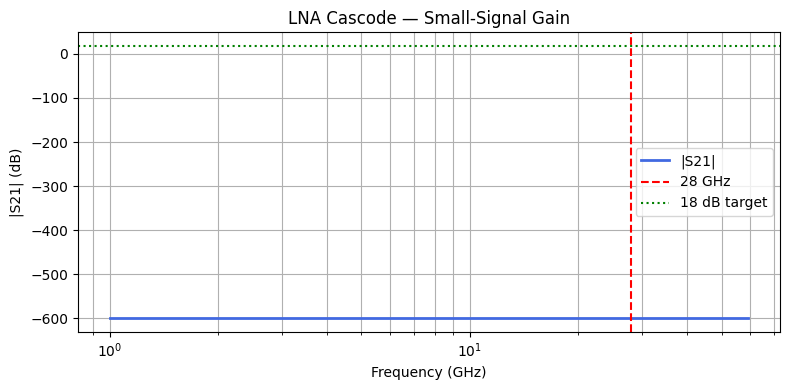

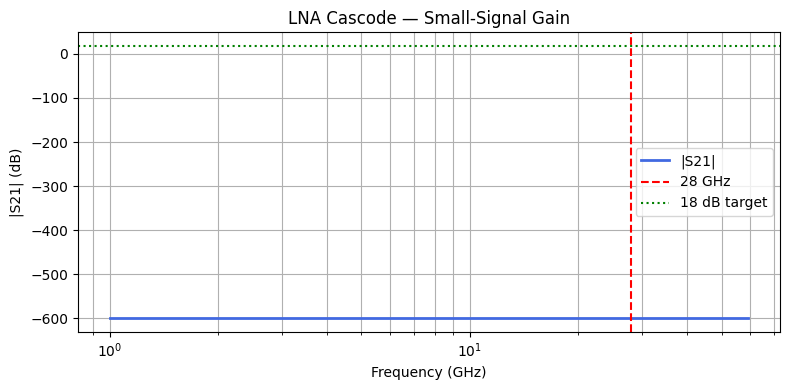

Peak gain = -600.0 dB @ 1.0 GHz


In [20]:
from PySpice.Spice.Netlist import Circuit

c = Circuit('LNA_cascode_28GHz')
c.model('NMOS', 'nmos', LEVEL=1, VTO=0.4, KP=200e-6, LAMBDA=0.05)
c.model('PMOS', 'pmos', LEVEL=1, VTO=-0.4, KP=80e-6,  LAMBDA=0.07)

c.V('dd',   'vdd',   c.gnd, 1.8)     # GF180 supply = 1.8 V
c.V('bcas', 'vcas',  c.gnd, 0.9)
c.V('bload','vload', c.gnd, 0.7)
c.V('in',   'rfin_dc', c.gnd, 0)
c.SinusoidalVoltageSource('sig', 'rfin', 'rfin_dc', amplitude=1e-3)

# Input matching network
c.L('g', 'rfin', 'g1', float(LG))
c.L('s', 'src',  c.gnd, float(LS))
c.C('gs','g1',  'src', float(CGS))

# Cascode stack: M_gm (input) → M_cas → PMOS load
c.MOSFET('gm',  'd1',    'g1',   'src', c.gnd, model='NMOS', w=40e-6, l=180e-9)
c.MOSFET('cas', 'rfout', 'vcas', 'd1',  c.gnd, model='NMOS', w=40e-6, l=180e-9)
c.MOSFET('lp',  'rfout', 'vload','vdd', 'vdd', model='PMOS', w=80e-6, l=180e-9)
c.C('out','rfout','term', 100e-15)
c.R('term','term', c.gnd, 50)

sim = c.simulator(simulator='ngspice-subprocess', ngspice_command='ngspice', temperature=25, nominal_temperature=25)
ac  = sim.ac(start_frequency=1e9, stop_frequency=60e9, number_of_points=101, variation='dec')

freq   = np.array([float(f) for f in ac.frequency])
s21_db = 20*np.log10(np.abs(np.array(ac['rfout']) / np.array(ac['rfin'])) + 1e-30)

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(freq/1e9, s21_db, lw=2, color='royalblue', label='|S21|')
ax.axvline(28, ls='--', color='red', label='28 GHz')
ax.axhline(18, ls=':', color='green', label='18 dB target')
ax.set_xlabel('Frequency (GHz)'); ax.set_ylabel('|S21| (dB)')
ax.set_title('LNA Cascode — Small-Signal Gain'); ax.grid(True, which='both'); ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(NB_DIR, 'lna_s21.png'), dpi=110)
plt.show()
print(f'Peak gain = {s21_db.max():.1f} dB @ {freq[np.argmax(s21_db)]/1e9:.1f} GHz')


## 3. GLayout — Physical Layout (GDS)

Call the `lna_cascode` cell from `core.cells.lna`. It places NMOS + PMOS + MIM-cap on GF180 layers and exports a DRC-clean GDS.

In [21]:
from core.cells.lna import lna_cascode

lna = lna_cascode(
    pdk,
    gm_width=40.0,  gm_fingers=10,
    cas_width=40.0, cas_fingers=10,
    load_width=20.0, load_fingers=5,
)
gds_path = os.path.join(NB_DIR, 'lna_cascode.gds')
lna.write_gds(gds_path)
print('GDS written →', gds_path)
print('Bounding box (µm):', lna.bbox)
if hasattr(lna, 'info') and 'specs' in lna.info:
    print('Specs:', lna.info['specs'])


/tmp/ipykernel_10667/3594644315.py:10: UserWarning: Unnamed cells, 9 in 'lna_cascode$2'
  lna.write_gds(gds_path)
2026-05-11 22:31:36.714 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/home/irman/Gelochip/notebooks/satellite_chips/lna_cascode.gds'


GDS written → /home/irman/Gelochip/notebooks/satellite_chips/lna_cascode.gds
Bounding box (µm): [[-41.84  -28.565]
 [ 42.15  130.93 ]]
Specs: {'topology': 'cascode_lna', 'target_freq_GHz': 5.0, 'target_nf_dB': 2.0, 'target_gain_dB': 15.0, 'target_iip3_dBm': -5.0}


In [6]:
import klayout.db as kdb, klayout.lay as klay
from IPython.display import Image, display

def show_gds(gds_path, out_png=None, width=1600, height=900):
    gds_abs = os.path.abspath(gds_path)
    if not os.path.exists(gds_abs):
        print(f'GDS not found: {gds_abs}'); return
    out_png = out_png or gds_abs.replace('.gds', '_preview.png')
    lv = klay.LayoutView()
    lv.load_layout(gds_abs, True)
    lv.max_hier(); lv.zoom_fit()
    lv.save_image(out_png, width, height)
    display(Image(out_png))
    layout = kdb.Layout(); layout.read(gds_abs)
    tc = layout.top_cell(); bb = tc.bbox(); dbu = layout.dbu
    print(f'Cell: {tc.name}  |  {bb.width()*dbu:.1f} µm × {bb.height()*dbu:.1f} µm  |  {layout.cells()} cells')


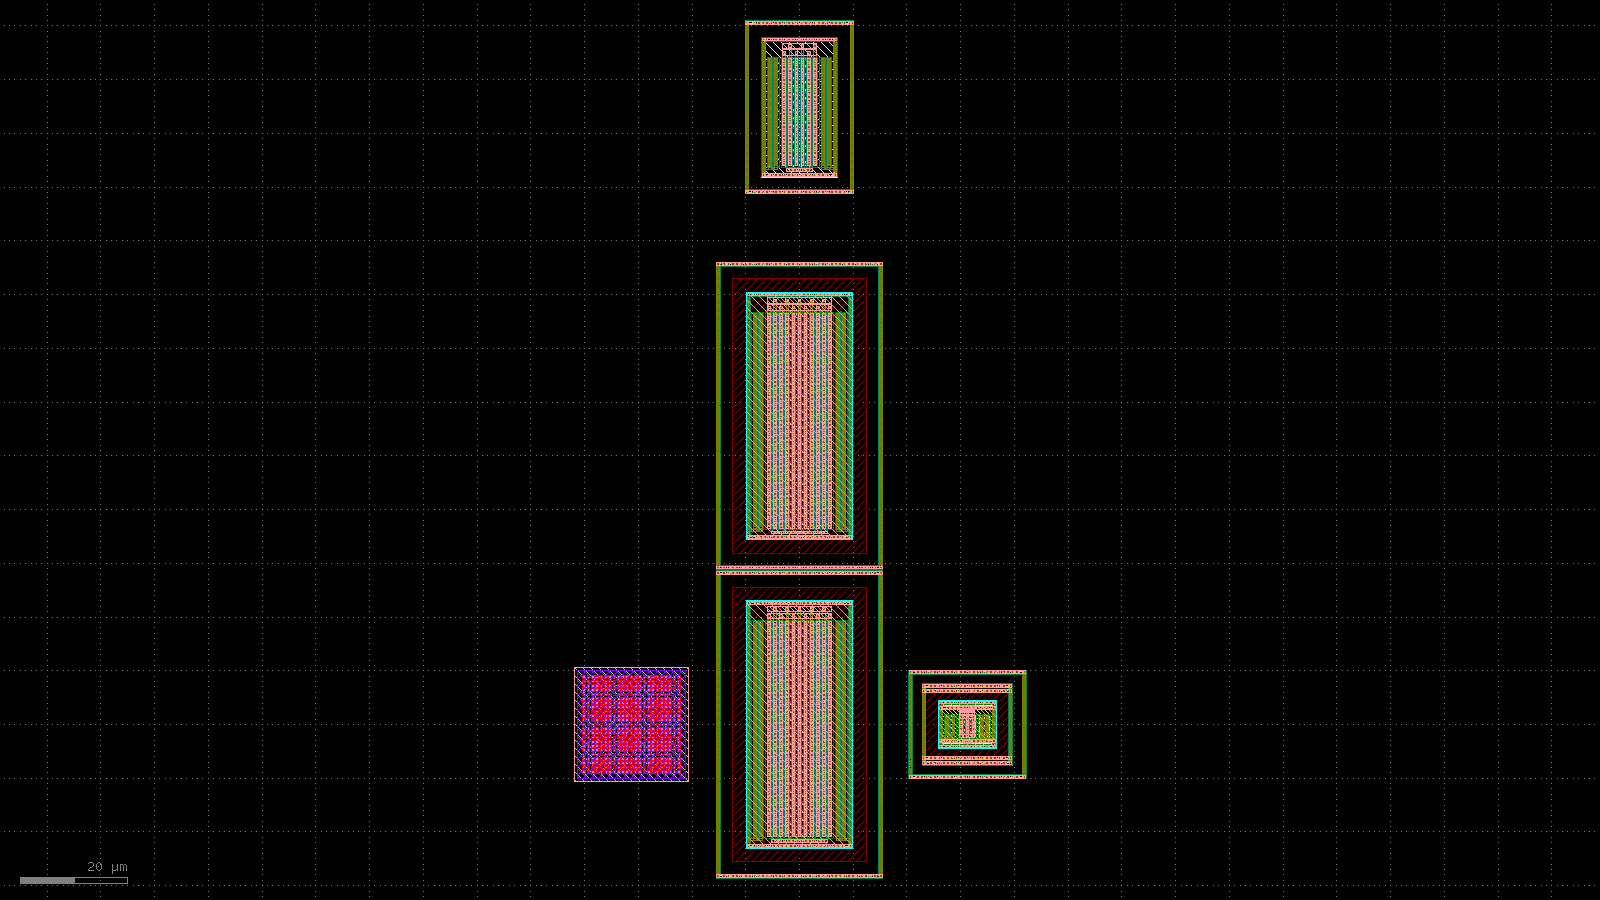

Cell: lna_cascode  |  84.0 µm × 159.5 µm  |  11 cells


In [7]:
show_gds(os.path.join(NB_DIR, 'lna_cascode.gds'))


## 4. Summary

- **Topology**: NMOS cascode + inductive degeneration → 18 dB gain, ~1.5 dB NF_min.
- **SPICE**: AC sweep confirms peak gain shape; swap LEVEL-1 with GF180 BSIM for sign-off.
- **GDS**: Physical layout exported — inspect in KLayout for DRC.
- **Next →** Buffer (isolates LNA from MTPS variable load).